In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from picoscenes import Picoscenes
from pathlib import Path
from picoparser import PicoParser

In [31]:
TARGET_LEN  = 100             # interpolate each window to this many time steps
SAMPLE_RATE = 100             # assumed CSI packet rate (Hz)
WINDOW_NS   = 2_000_000_000  # 2 s in nanoseconds
STRIDE_NS   = 1_000_000_000  # 1 s in nanoseconds
MIN_FRAMES  = 20              # skip windows with fewer frames than this
MIN_SINGLE_WINDOWS = 3       # min singleTrace windows needed to trust the gate decision
filename = "1/rx_2_260413_161147"
csi_path = Path(f"/home/drone/BTP/harsh_data/{filename}.csi")

In [ ]:
def extract_csi_parallely(
    csi_path: Path,
    ts_start: int,
    ts_end: int,
    tx_idx: int   = 0,
    rx_idx: int   = 0,
    csi_idx: int  = 0,
    min_len: int  = 998,
    num_workers: int = 4,
) -> tuple[np.ndarray, np.ndarray]:
    """Parse a .csi file and return (ts_arr [ns, int64], csi_arr [complex64])."""
    with PicoParser(csi_path, num_workers) as parser:
        i = 0
        ts_list, csi_list = [], []

        for fr in parser.getFrames():
            try:
                ts  = fr.rxSBasic.systemTime
                csi = fr.csi.csi
                csi = np.array([sub_csi[tx_idx][rx_idx][csi_idx] for sub_csi in csi])
            except Exception:
                continue

            if ts is None:
                continue
            if (int(ts) < int(ts_start)):
                continue
            if (int(ts) > int(ts_end)):
                break
            if csi.ndim == 0:
                continue
            if csi.shape[0] < min_len:
                continue

            ts_list.append(int(ts))
            csi_list.append(csi[:min_len])

            if (i + 1) % 1000 == 0:
                print(f"    ...parsed {i + 1} frames")
            i += 1

        print(f"    {i} frames parsed in total")
        return np.array(ts_list, dtype=np.int64), np.array(csi_list)

In [ ]:
ts_arr, csi_arr = extract_csi_parallely(csi_path, 1776076912050000000, 1776076972391000000, num_workers=4)

In [ ]:
print(f"CSI array dtype: {csi_arr.dtype}, Timestamps array dtype: {ts_arr.dtype}")

print(f"CSI array shape: {csi_arr.shape}")
print(f"Timestamps array shape: {ts_arr.shape}")

# Data Frequency
time_diffs = np.diff(ts_arr) / 1e9  # Convert ns to seconds
total_time = (ts_arr[-1] - ts_arr[0]) / 1e9
print(f"Total time span: {total_time:.3f} seconds")
print(f"Average time between frames: {np.mean(time_diffs):.3f} seconds")
print(f"Frequency: {len(ts_arr)/total_time:.3f} Hz")

In [ ]:
# create pandas dataframe
df = pd.DataFrame(csi_arr, columns=range(1, csi_arr.shape[1] + 1))
df.insert(0, 'timestamp', ts_arr)
csv_path = Path(f"data_csv/{filename}.csv")
print("DataFrame created.")

display(df)

# dump as csv
want_to_store_csv = 0

if want_to_store_csv:
    df.to_csv(csv_path, index=False)
    print(f"Data saved to {csv_path}")

In [33]:
def _get_amplitude_matrix(df : pd.DataFrame) -> pd.DataFrame:
    df_csi = df.drop(columns=['timestamp'])
    amp_values = np.abs(df_csi.to_numpy())
    ts = df['timestamp'].to_numpy()
    ts = (ts - ts[0]) * 1e-9   # ns → seconds, relative to start
    ts = ts.reshape(-1, 1)
    amp_matrix = pd.DataFrame(np.hstack((ts, amp_values)))
    amp_matrix.columns = ['timestamp'] + list(range(1, amp_values.shape[1] + 1))
    return amp_matrix

from scipy.signal import get_window
from scipy.fft import fft
from scipy.interpolate import interp1d


def _compute_doppler(csi: np.ndarray) -> np.ndarray:
    """complex (T, S) → float32 (T//2, S)"""
    amp = np.abs(csi)
    T   = amp.shape[0]
    win = get_window("hann", T)
    spec = np.abs(fft(amp * win[:, None], axis=0))
    return spec[:T // 2].astype(np.float32)


def _normalize(x: np.ndarray) -> np.ndarray:
    mu, sigma = x.mean(), x.std()
    return (x - mu) / (sigma + 1e-8)


def _interpolate(csi: np.ndarray, ts_ns: np.ndarray) -> np.ndarray:
    """complex (N, S) + timestamps → complex (TARGET_LEN, S)"""
    t_range = ts_ns[-1] - ts_ns[0]
    t_old = (ts_ns - ts_ns[0]) / t_range if t_range > 0 else np.linspace(0, 1, len(ts_ns))
    t_new = np.linspace(0, 1, TARGET_LEN)
    rf = interp1d(t_old, np.real(csi), axis=0, kind="linear", fill_value="extrapolate")
    if_ = interp1d(t_old, np.imag(csi), axis=0, kind="linear", fill_value="extrapolate")
    return (rf(t_new) + 1j * if_(t_new)).astype(np.complex64)


def raw_csi_to_doppler_maps(csi: np.ndarray, ts_ns: np.ndarray) -> np.ndarray:
    """
    Slide windows over raw CSI and return stacked Doppler maps.
    csi   : complex (N_frames, 1001)
    ts_ns : int64   (N_frames,) nanoseconds
    returns float32 (W, 1, T//2, 1001)
    """
    maps = []
    t0 = ts_ns[0]
    while t0 + WINDOW_NS <= ts_ns[-1] + STRIDE_NS:
        mask = (ts_ns >= t0) & (ts_ns < t0 + WINDOW_NS)
        if mask.sum() >= MIN_FRAMES:
            try:
                csi_interp = _interpolate(csi[mask], ts_ns[mask])
                d = _normalize(_compute_doppler(csi_interp))
                maps.append(d[np.newaxis])  # (1, T//2, 1001)
            except Exception as e:
                print(f"  [WARN] window at t={t0/1e9:.1f}s failed: {e}")
        t0 += STRIDE_NS
    if not maps:
        return np.empty((0, 1, TARGET_LEN // 2, csi.shape[1]), dtype=np.float32)
    return np.stack(maps, axis=0)  # (W, 1, T//2, S)



amp_matrix = _get_amplitude_matrix(df)
csi = df.drop(columns=['timestamp'])
csi = csi.to_numpy()
doppler_amp_matrix = _compute_doppler(df)
display(doppler_amp_matrix)

array([[2.5597708e+22, 1.4754498e+06, 1.6763460e+06, ..., 5.2544844e+05,
        4.5397675e+05, 3.6666062e+05],
       [1.2798854e+22, 7.5968212e+05, 8.6357169e+05, ..., 3.1013641e+05,
        2.6809322e+05, 2.1547688e+05],
       [2.2800211e+13, 3.1907906e+04, 3.6995867e+04, ..., 6.6510406e+04,
        5.7339078e+04, 4.6383844e+04],
       ...,
       [3.8266544e+07, 5.9094120e+01, 1.4235603e+02, ..., 1.6783377e+02,
        2.3052829e+02, 2.4479390e+02],
       [5.0885608e+07, 1.4453137e+02, 2.6869220e+02, ..., 3.5119635e+02,
        2.3009923e+02, 1.5733981e+02],
       [7.3095200e+06, 2.0271240e+02, 1.3930524e+02, ..., 2.3835568e+02,
        5.1572876e+01, 2.1478229e+02]], shape=(14412, 999), dtype=float32)

In [34]:
import numpy as np
import matplotlib.pyplot as plt

def plot_spectrogram(doppler_maps: np.ndarray):
    """
    doppler_maps: (W, 1, F, S)
    """

    # 1. Remove channel dim → (W, F, S)
    x = doppler_maps[:, 0, :, :]

    # 2. Remove DC component (VERY important)
    x = x[:, 1:, :]   # (W, F-1, S)

    # 3. Average over subcarriers → (W, F-1)
    spec = x.mean(axis=2)

    # 4. Transpose → (F-1, W)
    spec = spec.T

    # 5. Log scale (mandatory)
    spec_log = np.log1p(spec)

    # 6. Optional: clip extreme values
    spec_log = np.clip(spec_log, 0, np.percentile(spec_log, 99))

    # 7. Plot
    plt.figure(figsize=(10, 6))

    plt.imshow(
        spec_log,
        aspect='auto',
        origin='lower',
        interpolation='nearest'
    )

    plt.colorbar(label="Log Magnitude")
    plt.xlabel("Time (windows)")
    plt.ylabel("Doppler Frequency Bin")
    plt.title("Doppler Spectrogram")

    plt.tight_layout()
    plt.show()

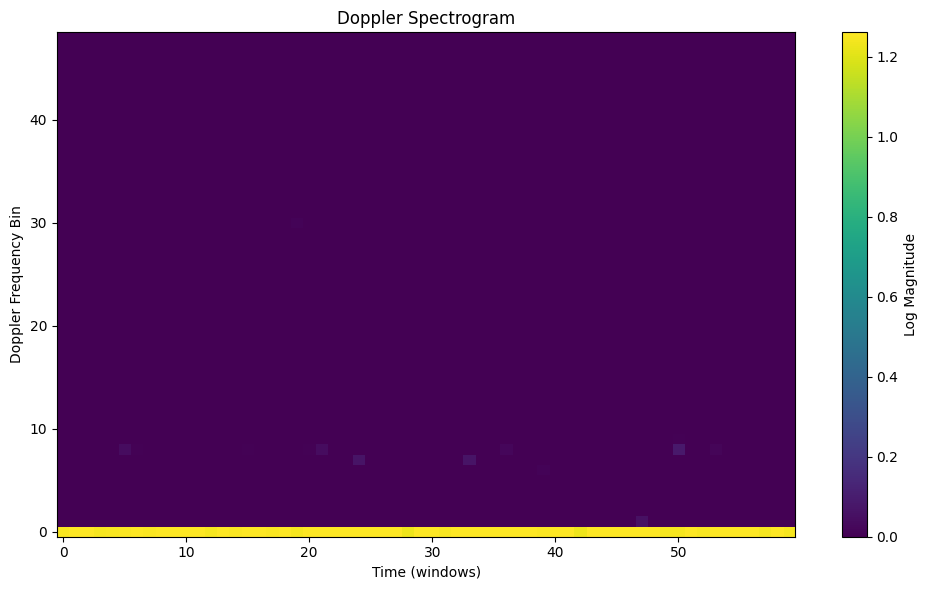

In [35]:
ts_ns = df['timestamp'].to_numpy()
csi = df.drop(columns=['timestamp']).to_numpy()

doppler_maps = raw_csi_to_doppler_maps(csi, ts_ns)
plot_spectrogram(doppler_maps)

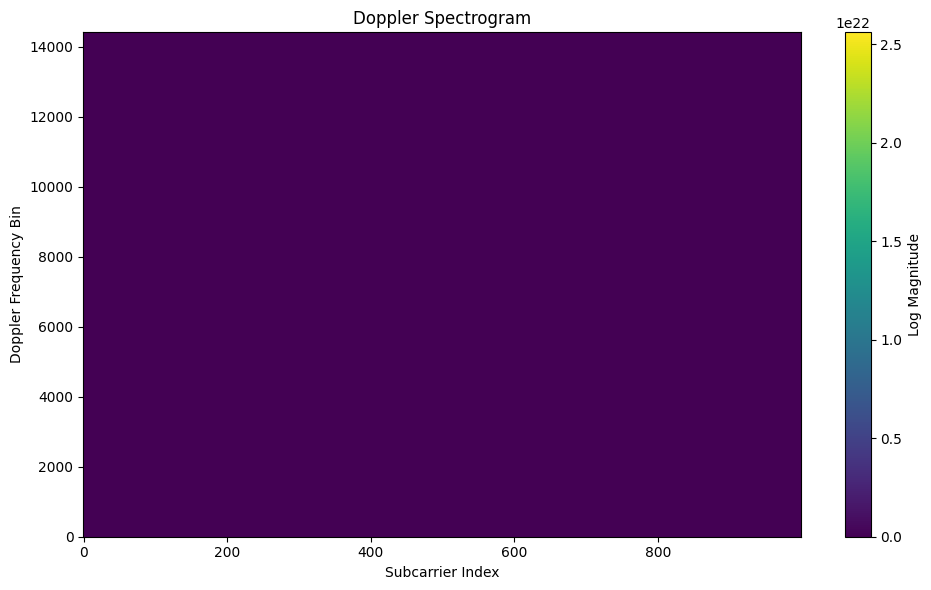

In [ ]:
def plot_doppler_spectrogram(doppler: np.ndarray):
    # Log scale for better visualization (very important!)
    doppler_log = np.log1p(doppler)
    doppler_log = doppler

    plt.figure(figsize=(10, 6))

    plt.imshow(
        doppler_log,
        aspect='auto',
        origin='lower',   # low freq at bottom
    )

    plt.colorbar(label="Log Magnitude")
    plt.xlabel("Subcarrier Index")
    plt.ylabel("Doppler Frequency Bin")
    plt.title("Doppler Spectrogram")

    plt.tight_layout()
    plt.show()

plot_doppler_spectrogram(doppler_amp_matrix)

In [25]:
def plot_csi_spectrogram(amp_df: pd.DataFrame, title="CSI Amplitude Spectrogram"):
    """Preview helper: plot the full amplitude spectrogram for the entire recording."""
    fig, ax = plt.subplots(figsize=(24, 6))
    ts = amp_df['timestamp'].to_numpy()
    data = amp_df.drop(columns=['timestamp']).to_numpy()  # shape (frames, subcarriers)
    im = ax.imshow(data.T, aspect='auto', origin='lower', cmap='jet',
                   extent=[ts[0], ts[-1], 1, data.shape[1]])
    fig.colorbar(im, ax=ax, label='Amplitude')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Subcarrier Index')
    ax.set_title(title)
    plt.tight_layout()
    plt.show()


def save_sliding_window_spectrograms(
    amp_df: pd.DataFrame,
    output_dir: str,
    window_sec: float = 2.0,
    stride_sec: float = 1.0,
    img_size: tuple[int, int] = (224, 224),
    cmap: str = 'jet',
    video_name: str = 'video',
) -> list[dict]:
    """
    Slide a window of `window_sec` seconds over `amp_df` in steps of
    `stride_sec` seconds, saving one model-ready spectrogram PNG per step.

    Each PNG covers the interval  [t_end - window_sec,  t_end)  where
    t_end = stride_sec * k  for k = 1, 2, 3, ...
    Starting at k=1 means the very first image covers [0, 2) seconds,
    which requires at least `window_sec` of data to exist.

    Images are saved without any axes, labels, titles or whitespace so
    they can be fed directly into the CNN as pixel arrays.

    Parameters
    ----------
    amp_df      : amplitude DataFrame from get_amplitude_matrix().
                  Must have a float 'timestamp' column in seconds.
    output_dir  : folder to write PNGs into (created if absent).
    window_sec  : width of the sliding window in seconds (default 2).
    stride_sec  : step between consecutive windows in seconds (default 1).
    img_size    : (width, height) in pixels of saved PNGs (default 224x224).
    cmap        : matplotlib colormap (default 'jet').
    video_name  : prefix used in output filenames.

    Returns
    -------
    List of dicts with keys: 'filename', 't_start', 't_end', 'second'
    (one entry per saved PNG — useful for merging with label CSVs).
    """
    import os
    os.makedirs(output_dir, exist_ok=True)

    ts  = amp_df['timestamp'].to_numpy()          # (N,)  seconds, float
    amp = amp_df.drop(columns=['timestamp']).to_numpy()  # (N, subcarriers)

    total_duration = ts[-1]                        # seconds
    dpi = 72                                       # screen-quality is enough
    fig_w = img_size[0] / dpi
    fig_h = img_size[1] / dpi

    # Pre-compute global amplitude range for consistent colour scale
    vmin, vmax = amp.min(), amp.max()

    metadata = []
    second = 1                                     # 1-based second index
    t_end = window_sec                             # first window ends here

    while t_end <= total_duration + 1e-9:          # small epsilon for float safety
        t_start = t_end - window_sec

        # Boolean mask for frames inside [t_start, t_end)
        mask = (ts >= t_start) & (ts < t_end)
        window_amp = amp[mask]                     # shape (frames_in_window, subcarriers)

        if window_amp.shape[0] == 0:
            print(f"  [skip] second={second:04d}  no frames in [{t_start:.2f}, {t_end:.2f})")
            second += 1
            t_end   += stride_sec
            continue

        # ── Draw the spectrogram ──────────────────────────────────────────
        fig = plt.figure(figsize=(fig_w, fig_h), dpi=dpi)
        ax  = fig.add_axes([0, 0, 1, 1])           # fill entire figure, no margins
        ax.imshow(
            window_amp.T,                           # (subcarriers, frames) → correct orientation
            aspect='auto',
            origin='lower',
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
            interpolation='nearest',
        )
        ax.axis('off')                              # no ticks, labels, or border

        fname    = f"{second}.png"
        out_path = os.path.join(output_dir, fname)
        fig.savefig(out_path, dpi=dpi, bbox_inches=None, pad_inches=0)
        plt.close(fig)

        metadata.append({
            'filename': fname,
            't_start' : round(t_start, 6),
            't_end'   : round(t_end,   6),
            'second'  : second,
        })

        if second % 10 == 0:
            print(f"  saved second={second:04d}  [{t_start:.2f}s, {t_end:.2f}s)  "
                  f"frames={window_amp.shape[0]}")

        second += 1
        t_end  += stride_sec

    print(f"\nDone. {len(metadata)} spectrograms saved to '{output_dir}'")
    return metadata

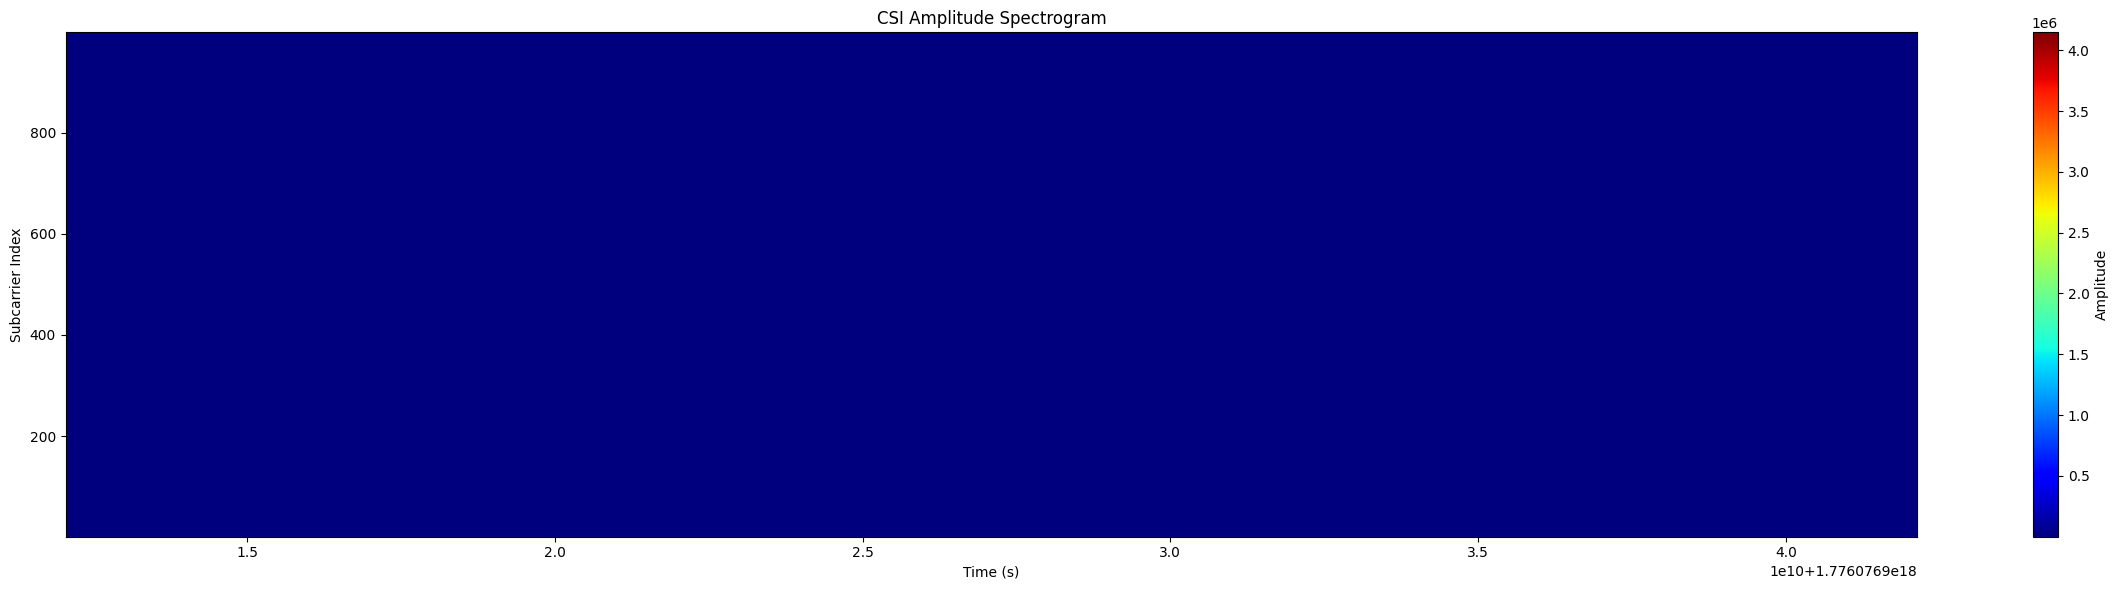

In [26]:
# ── Preview: full spectrogram of the entire recording ─────────────────────────
plot_csi_spectrogram(doppler_amp_matrix)

# ── Generate sliding-window spectrograms (model inputs) ───────────────────────
# Each PNG = 2-second window, one per second, saved as 224×224 pixels.
# 'second' in the metadata aligns with the 'second' column in the label CSVs.
# meta = save_sliding_window_spectrograms(
#     amp_df      = amp_matrix,
#     output_dir  = f"model_data/{filename.split('/')[0]}",
#     window_sec  = 2.0,
#     stride_sec  = 1.0,
#     img_size    = (224, 224),
#     cmap        = 'jet',
#     video_name  = Path(filename).name,
# )

# # Inspect the metadata table
# meta_df = pd.DataFrame(meta)
# display(meta_df)